# Week 2: Iterační metody pro řešení lineárních algebraických systémů

**Assignment:** [![Run in JupyterHub](https://img.shields.io/badge/Run%20in-JupyterHub-F37626?logo=jupyter)](https://hpc.troja.mff.cuni.cz:8000/hub/user-redirect/git-pull?app=lab&repo=https%3A%2F%2Fgitlab.karlin.mff.cuni.cz%2Fznm%2Fcviceni-student&branch=main&subpath=notebooks%2Fassignment%2Fweek-02-iterative-methods.ipynb) [![Download .ipynb](https://img.shields.io/badge/Download-.ipynb-blue)](https://gitlab.karlin.mff.cuni.cz/znm/cviceni-student/-/raw/main/notebooks/assignment/week-02-iterative-methods.ipynb?inline=false) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/num-math/cviceni-student/blob/main/notebooks/assignment/week-02-iterative-methods.ipynb)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Materiály

- [poznámky z přednášky](https://www.karlin.mff.cuni.cz/~blechta/znm/assets/Reseni_soustav.pdf)
- další materiály
  - kniha [Duintjer Tebbens a kolektiv: Analýza metod pro maticové výpočty](https://cuni.primo.exlibrisgroup.com/discovery/fulldisplay?docid=alma990020832750106986&context=L&vid=420CKIS_INST:UKAZ&lang=cs&search_scope=MyInst_and_CI&adaptor=Local%20Search%20Engine&tab=Everything&query=any,contains,Anal%C3%BDza%20metod%20pro%20maticov%C3%A9%20v%C3%BDpo%C4%8Dty&offset=0)  (Sekce 9.1)
  - kniha [Y. Saad: Iterative Methods for Sparse Linear Systems](https://www-users.cse.umn.edu/~saad/IterMethBook_2ndEd.pdf) (Kapitola 4; bible oboru)
  - skripta [Foundations of Applied Mathematics](https://foundations-of-applied-mathematics.github.io/) (Volume 1, Kapitola 15)

- ***Primární úlohy*** : A1, A2, B1

- ***Úlohy k bonusové části zkoušky*** : A1, A2

- základní ***Learning outcomes*** (cviko, nikoliv přednáška)
  - Umím pro dané štěpení matice $A$ odvodit podmínky na konvergenci odpovídající stacionární metody.
  - Z grafů v lineárním, semilogaritmickém i logaritmickém (na obou osách) měřítku určím asymptotický řád konvergence.
  - Umím vysvětlit rozdíl v konvergenci stacionárních metod pro případ, kdy je iterační matice symetrická a kdy diagonalizovatelná, ale nikoliv pomocí unitární transformace.
  - Pro danou stacionární metodu dokážu odvodit její formulaci jako polynomiální metody.

## Intro

První, klasický způsob řešení

<a name="eq1"></a>
\begin{equation*}
\tag{1}
A\mathbf{x} = \mathbf{b}
\end{equation*}

jsme už částečně potkali v [minulém cviku](week-01-conditioning-stability) - Gaussova eliminace s částečnou pivotací (nebo ekvivalentně LU rozklad a odpovídající problémy s trojúhelníkovými maticemi). Dvě hlavní nevýhody jsou

> Nemůžeme jednoduše ovlivnit přesnost řešení:
  - v mnoha (téměř ve většině) aplikacích máme data z reálného měření/simulací, které jsou sami o sobě zatížené nějakou chybou - většinou výrazně vyšší než $\varepsilon_{mach}$. Pokud víme, že $A$ a $\mathbf{b}$ jsou zatíženy chybou řádu $\delta \gg \varepsilon_{mach}$, dává smysl se ptát na řešení splňující [(1)](#eq1) pouze na úrovni $\delta$ - například můžeme hledat $\mathbf{x}_{\delta}$ takové, že platí pouze
  \begin{equation*} \| \underbrace{ \mathbf{b} - A \mathbf{x}_{\delta} }_{=: \, \mathbf{r}_{\delta} \, \leftarrow \, \mathrm{ tzv. \; reziduum}} \| \approx \delta. \end{equation*}
  Gaussova eliminace nám nic takového sama o sobě neumožňuje a tedy musíme "ztrácet čas" výpočtem $\mathbf{x}$ v přesnosti $\varepsilon_{mach}$. Jednou možností jak umožnit "kontrolu přesnosti řešení" v průběhu výpočtu jsou iterační metody.
  - alternativní formulace téhle nevýhody je, že nejsme schopni kontrolovat čas výpočtu. Pokud víme, že máme na výpočet pouze několik vteřin/minut, protože pak už je výsledek bezcenný (např. předpověď počasí, trading na burzách, ...) a náš odhad časové náročnosti Gaussovy eliminace
  \begin{equation*}\# \,\mathrm{flops} \sim \frac{2}{3}n^3 + \mathcal{O}(n^2)\end{equation*}
  predikuje, že řešení [(1)](#eq1) bude trvat déle, pak zjevně potřebujeme jiný postup. Jednou možností jsou iterační metody.

> Nemáme safety-points:
  - podle věty o stabilitě LU rozkladu s částečnou pivotací (a tedy Gaussovy eliminace) můžeme stabilitu výpočtu monitorovat v průběhu samotného výpočtu - stačí kontrolovat velikosti prvků v již spočtených částech matic $L$ a $U$ (v porovnání s velikostmi prvků $A$). Ovšem v [minulém cvičení](week-01-conditioning-stability) jsme viděli, že na problém můžeme narazit až u konce tohoto procesu - pro Wilkinsonovy matice $W_n$ nám stabilita exponenciálně klesala s počtem kroků, které už jsme v procesu LU-rozkladu udělali.
  - Může se tedy stát, že po hodinách a hodinách výpočtu stabilitu "úplně ztratíme" (tj. až po těch hodinách výpočtu uvidíme, že námi vypočtený LU-rozklad není dostatečně stabilní) a musíme začít opět úplně od začátku. Nemáme žádné "přibližné řešení", nic čím bychom mohli ty hodiny výpočtu "obhájit". Přirozenou možností jak toto napravit jsou iterační metody.


Přímé metody pro řešení [(1)](#eq1) (jako například LU rozklad, ale uvidíme v průběhu první půlky semestru i další), po nějaké době výpočtu, vydají jedno numerické řešení. Myšlenka iteračních metod je principálně odlišná, spočívá v konstrukci *posloupnosti aproximací* (přibližných řešení) $\mathbf{x}_0, \mathbf{x}_1, \mathbf{x}_2, \ldots $, která by se měla přibližovat skutečnému řešení $\mathbf{x}$.

## Část A: Klasické iterační metody (aka [stacionární](https://en.wikipedia.org/wiki/Iterative_method#Stationary_iterative_methods))

### Shrnutí látky z přednášky & značení

Klasické iterační metody jsou založeny na štěpení matice soustavy $A = M-N$, kde matice $M$ je regulární a umíme efektivně řešit problémy typu $M\mathbf{x} = \mathbf{b}$.

Dosazením do vztahu $A\mathbf{x}=\mathbf{b}$ postupně dostáváme

\begin{equation*} (M-N)\mathbf{x} = \mathbf{b} \end{equation*}
\begin{equation*} M\mathbf{x} = N\mathbf{x} + \mathbf{b} \end{equation*}
\begin{equation*} \mathbf{x} = M^{-1}N\mathbf{x} + M^{-1}\mathbf{b}. \end{equation*}

Máme-li počáteční aproximaci řešení $\mathbf{x}_0$, pak můžeme nastartovat iterační proces
\begin{equation*} \mathbf{x}_k = M^{-1}N \mathbf{x}_{k-1} + M^{-1}\mathbf{b}. \end{equation*}

Klasické iterační metody jsou založeny na štěpení ve tvaru

\begin{equation*}
A =
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\underbrace{ \begin{bmatrix}
a_{1,1} & 0 & \cdots & 0 \\
0 & \ddots & \ddots & \vdots \\
\vdots & \ddots & \ddots & 0 \\
0 & \cdots & 0 & a_{n,n} \\
\end{bmatrix} }_{=: \, D} -
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\underbrace{ \begin{bmatrix}
0 & 0 & \cdots & 0 \\
-a_{2,1} & \ddots & \ddots & \vdots \\
\vdots & \ddots & \ddots & 0 \\
-a_{n,1} & \cdots & -a_{n,n-1} & 0 \\
\end{bmatrix} }_{=: \, L} -
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
\underbrace{ \begin{bmatrix}
0 & -a_{1,2} & \cdots & -a_{1,n} \\
0 & \ddots & \ddots & \vdots \\
\vdots & \ddots & \ddots & -a_{n-1,n} \\
0 & \cdots & 0 & 0 \\
\end{bmatrix} }_{=: \, U}\end{equation*}

kde $D$ je hlavní diagonála, $-L$ je striktně dolní trojúhelník matice $A$ a $-U$ je striktně horní trojúhelník matice $A$.

- V [Jacobiho metodě](https://en.wikipedia.org/wiki/Jacobi_method) volíme $M=D$, $N = L+U$, a je tedy definována iterací
\begin{equation*}D \mathbf{x}_{k} = (L + U)\mathbf{x}_{k-1} +\mathbf{b},\end{equation*}

- [Gaussova-Seidelova metoda](https://en.wikipedia.org/wiki/Gauss%E2%80%93Seidel_method) používá $M=D-L$, $N = U$ a je definována jako
\begin{equation*} (D-L) \mathbf{x}_{k} = U \mathbf{x}_{k-1} +\mathbf{b}.\end{equation*}


- Další metodou, která je (po jistých adaptacích) užitečná je [Richardsonova metoda](https://en.wikipedia.org/wiki/Modified_Richardson_iteration), která odpovídá volbě $M=I$, $N = I-A$, a je tedy definována iterací
\begin{equation*} \mathbf{x}_{k} = (I-A)\mathbf{x}_{k-1} +\mathbf{b} = \mathbf{x}_{k-1} + (\mathbf{b} - A\mathbf{x}_{k-1}).\end{equation*}


Pro analýzu klasických iteračních metod je důležitý vztah mezi chybami dvou následujících přibližných řešení, tj. mezi $\mathbf{e}_{k} :=\mathbf{x} - \mathbf{x}_{k}$ a $\mathbf{e}_{k-1} := \mathbf{x}_{k} - \mathbf{x}_{k-1}$:

\begin{equation*}
\mathbf{e}_{k} = M^{-1}N \mathbf{e}_{k-1} = (I - M^{-1}A) \mathbf{e}_{k-1}  = \cdots = (I - M^{-1}A)^k \mathbf{e}_{0},
\end{equation*}

který jsme viděli na přednášce. Říká nám, že pokud chceme aby chyba $\mathbf{e}_{k} = \mathbf{x} - \mathbf{x}_{k}$ konvergovala k $\mathbf{0}$ pro libovolné $\mathbf{e}_{0}$, pak nutně musí platit

\begin{equation*} (I - M^{-1}A)^k \longrightarrow 0 \qquad \mathrm{pro} \; k\rightarrow +\infty. \end{equation*}

Opět z přednášky víme, že

\begin{equation*} (I - M^{-1}A)^k \longrightarrow 0 \quad \mathrm{pro} \; k\rightarrow +\infty  \quad \iff \quad \underbrace{ \left( \max\limits_{\lambda \, \mathrm{je \, vl. \, cislo \,} I - M^{-1}A }  \, |\lambda| \right) }_{=: \, \rho(I - M^{-1}A) }  \; < 1. \end{equation*}

### Úloha A1 - implementace

<div style="border-left: 4px solid #0969da; background-color: #ddf4ff; padding: 0.75em 1em; border-radius: 4px; margin: 1em 0;">
<blockquote style="margin: 0; padding: 0; border: none;">

**📝 Kódění**

Naimplementujte funkce `jacobi_method()` a `gauss_seidel_method()` podle anotací níže.

- [Nápověda & hinty](#head-w02-hinty-a1)

</blockquote>
</div>

In [4]:
def jacobi_method(A, b, x0, n_iter):
    '''
    Implementace Jacobiho metody pro reseni "Ax=b" (*), ktera provede "n_iter" iteraci s pocatecnim odhadem "x0".

    Input
    -------
    A :  np.array dimenze "n-krat-n" s prvky np.float64. matice soustavy (*). Predpokladame, A je regularni a ze diagonalni prvky jsou nenulove.
    b :  np.array dimenze "n" s prvky np.float64. prava strana soustavy (*)
    x0 :  np.array dimenze "n" s prvky np.float64. pocatecni odhad na reseni soustavy (*)
    n_iter :  np.int32. Pocet iteraci algoritmu, n_iter > 0

    Output
    -------
    x_approx : np.array dimenze "(n_iter+1)-krat-n". Musi platit "x_approx[i,:] = xi", kde "xi" je i-ta aproximace (tj. na vystupu vracime celou posloupnost aproximaci, vcetne te nulte)
    '''
    x_approx = np.zeros((n_iter + 1, 1))
    x_approx[0, :] = x0

    M = np.diag(np.diag(A))
    N = - A + M
    M_inv = np.linalg.inv(M)

    for k in range(n_iter):
        x_approx[k + 1, :] = (M_inv@N)@x_approx[k, :] + M_inv@b

    return x_approx


def test_jacobi_method():
    x0 = np.array([0, 0, 0, 0])
    n_iter = 3

    A1 = np.array([[4, 0, 0, 0], [0, 3, 0, 0], [0, 0, 2, 0], [0, 0, 0, 1]])
    b1 = np.array([1, 1, 1, 1])
    x_approx1 = jacobi_method(A1, b1, x0, n_iter)
    assert x_approx1.shape == (4, 4), \
        "Output 'jacobi_method()' pro matici 4x4 a 'n_iter = 3' by mel mit rozmery 4x4, ale ma output rozmeru {}".format(x_approx1.shape)
    assert np.linalg.norm(x_approx1[0, :] - x0) < 1e-10, \
        "Podle anotace funkce 'jacobi_method()' by melo platit 'x_approx[0,:] == x0', ale kod nam vraci \n x_approx[0,:] = {}  a  x0 = {}".format(x_approx1[0, :], x0)
    assert np.linalg.norm(A1 @ x_approx1[1, :] - b1) < 1e-10, \
        "Pro 'A' diagonalni by mela Jacobiho metoda zkonvergovat v prvni iteraci, ale to se nedeje"

    A2 = np.array([[3, -1, 0, 0], [-1, 3, -1, 0], [0, -1, 3, -1], [0, 0, -1, 3]])
    b2 = np.array([1, 1, 1, 1])
    x_approx2 = jacobi_method(A2, b2, x0, n_iter)
    x1 = np.linalg.solve(np.diag(np.diag(A2)), b2)
    assert np.linalg.norm(x_approx2[1, :] - x1) < 1e-10, \
        "Pro 'x0 = 0' by mela Jacobiho metoda v prvni iteraci dat 'x1 = D^{-1} x0', ale to se nedeje"
    x2 = np.linalg.solve(np.diag(np.diag(A2)), (np.diag(np.diag(A2)) - A2) @ x1 + b2)
    assert np.linalg.norm(x_approx2[2, :] - x2) < 1e-10, \
        "Jacobiho metoda nepocita spravne - porad se s cvicicim"

    return "funkce 'jacobi_method()' je OK"

test_jacobi_method()

ValueError: could not broadcast input array from shape (4,) into shape (1,)

In [ ]:
def gauss_seidel_method(A, b, x0, n_iter):
    '''
    Implementace metody Gauss-Seidel pro reseni "Ax=b", ktera provede "n_iter" iteraci s pocatecnim odhadem "x0".

    Input
    -------
    A :  np.array dimenze "n-krat-n" s prvky np.float64. matice soustavy (*). Predpokladame, A je regularni a ze diagonalni prvky jsou nenulove.
    b :  np.array dimenze "n" s prvky np.float64. prava strana soustavy (*)
    x0 :  np.array dimenze "n" s prvky np.float64. pocatecni odhad na reseni soustavy (*)
    n_iter :  np.int32. Pocet iteraci algoritmu, n_iter > 0

    Output
    -------
    x_approx : np.array dimenze "(n_iter+1)-krat-n". Musi platit "x_approx[i,:] = xi", kde "xi" je i-ta aproximace (tj. na vystupu vracime celou posloupnost aproximaci, vcetne te nulte)
    '''
    x_approx = np.zeros((n_iter + 1, 1))
    x_approx[0, :] = x0

    D = np.diag(np.diag(A))
    low_tril = np.tril(A)
    M = 2D - low_tril
    M_inv = np.linalg.inv(M)

    for k in range(n_iter):
        x_approx[k + 1, :] = (M_inv@N)@x_approx[k, :] + M_inv@b

    return

def test_gauss_seidel_method():
    x0 = np.array([0, 0, 0, 0])
    n_iter = 3

    A1 = np.array([[4, 0, 0, 0], [1, 3, 0, 0], [1, 1, 2, 0], [1, 1, 1, 1]])
    b1 = np.array([1, 1, 1, 1])
    x_approx1 = gauss_seidel_method(A1, b1, x0, n_iter)
    assert x_approx1.shape == (4, 4), \
        "Output 'gauss_seidel_method()' pro matici 4x4 a 'n_iter = 3' by mel mit rozmery 4x4, ale ma output rozmeru {}".format(x_approx1.shape)
    assert np.linalg.norm(x_approx1[0, :] - x0) < 1e-10, \
        "Podle anotace funkce 'gauss_seidel_method()' by melo platit 'x_approx[0,:] == x0', ale kod nam vraci \n x_approx[0,:] = {}  a  x0 = {}".format(x_approx1[0, :], x0)
    assert np.linalg.norm(A1 @ x_approx1[1, :] - b1) < 1e-10, \
        "Pro 'A' dolni trojuhelnikovou by mela metoda Gauss-Seidel zkonvergovat v prvni iteraci, ale to se nedeje"

    A2 = np.array([[3, -1, 0, 0], [-1, 3, -1, 0], [0, -1, 3, -1], [0, 0, -1, 3]])
    b2 = np.array([1, 1, 1, 1])
    x_approx2 = gauss_seidel_method(A2, b2, x0, n_iter)
    x1 = np.linalg.solve(np.tril(A2), b2)
    assert np.linalg.norm(x_approx2[1, :] - x1) < 1e-10, \
        "Pro 'x0 = 0' by mela metoda Gauss-Seidel v prvni iteraci dat 'x1 = D^{-1} x0', ale to se nedeje"
    x2 = np.linalg.solve(np.tril(A2), (np.tril(A2) - A2) @ x1 + b2)
    assert np.linalg.norm(x_approx2[2, :] - x2) < 1e-10, \
        "Metoda Gauss-Seidel nepocita spravne - porad se s cvicicim"

    return "funkce 'gauss_seidel_method()' je OK"

test_gauss_seidel_method()

### Úloha A2 - analýza konvergence

Pokud jde o rychlost konvergence iteračních metod, říkáme, že konvergují ***lineárně*** s konvergenčním faktorem $\rho < 1$ na $\mathbb{R}^n$, pokud platí

<a name="eq2"></a>
\begin{equation*}
\tag{2}
\max\limits_{\mathbf{e}_0 \in \mathbb{R}^n} \; \left( \lim\limits_{k \rightarrow +\infty}  \frac{ \| \mathbf{e}_{k} \| }{ \| \mathbf{e}_{k-1} \| } \right) = \rho < 1.
\end{equation*}

Definici lze přirozeně upravit, pokud chceme mluvit o konvergenčním faktoru na podprostorech $\mathbb{R}^n$.

<div style="border-left: 4px solid #0969da; background-color: #ddf4ff; padding: 0.75em 1em; border-radius: 4px; margin: 1em 0;">
<blockquote style="margin: 0; padding: 0; border: none;">

**📝 Tužka a papír**

Vezměme si obecnou stacionární metodu založenou na štěpení $A = M-N$ ($M$ je regulární).

  - Předpokládejme, že matice $I - M^{-1}A$ je unitárně diagonalizovatelná a má vlastní vektory $\mathbf{u}_1,\dotsc , \mathbf{u}_n$ příslušné vlastním číslům $\lambda_1,\dotsc  ,\lambda_n$ (ne nutně seřazené podle velikosti absolutní hodnoty).

    - Odvoďte konvergenční faktor $\rho$ definovaný v [(2)](#eq2) v závislosti na spektrálním rozkladu iterační matice $I - M^{-1}A$.

    - Odvoďte konvergenční podmínky na podprostoru $\mathcal{U}_k := \mathrm{span} \left( \mathbf{u}_1,\dotsc , \mathbf{u}_k \right)$, tj. v případě, že $\mathbf{x}, \mathbf{x}_0 \in \mathrm{span} \left( \mathbf{u}_1,\dotsc , \mathbf{u}_k \right)$ pro nějaké $k\ll n$. Jak se změní konvergenční faktor?

    - Rozhodněte, zda konvergence musí být monotónní čí nikoliv.

  - Co se změní, pokud $I - M^{-1}A$ není unitárně diagonalizovatelná, ale pouze diagonalizovatelná? Jak bude vypadat konvergenční faktor? Rozhodněte, zda konvergence musí být monotónní čí nikoliv.

- **Navíc**: Co se změní, pokud $I - M^{-1}A$ není diagonalizovatelná, ale pouze jordanizovatelná? Jak bude vypadat konvergenční faktor? Rozhodněte, zda konvergence musí být monotónní čí nikoliv.

- [Nápověda & hinty](#head-w02-hinty-a2)

</blockquote>
</div>

### Úloha A3 - konvergence a její vykreslování

<div style="border-left: 4px solid #0969da; background-color: #ddf4ff; padding: 0.75em 1em; border-radius: 4px; margin: 1em 0;">
<blockquote style="margin: 0; padding: 0; border: none;">

**📝 Tužka a papír**

Velmi často se v numerických výpočtech a experimentech zajímáme o vývoj chyby - výše o velikost $\| \mathbf{e}_k \|$. Při její vizualizaci pak většinou používáme *logaritmické měřítko* - v našem případě to odpovídá vykreslování $\log_{10}( \| \mathbf{e}_k \| ) $ místo $\| \mathbf{e}_k \|$ v závislosti na $k$, viz [`plt.semilogy()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.semilogy.html).
  - předpokládejme, že $\| \mathbf{e}_k \| = \rho \| \mathbf{e}_{k-1} \|$ pro $k=1,.2,\dotsc$, tj. že vztah z definice lineární konvergence [(2)](#eq2) platí pro všechna $k$, nikoliv pouze limitně. Jak bude vypadat graf $\log_{10}( \| \mathbf{e}_k \| ) $ jako funkce $k$? Vysvětlete proč se konvergenci splňující [(2)](#eq2) říká *lineární*.

  - Jak by vypadal graf pokud v semilogaritmickém měřítku pokud je konvergence
    - ***superlineární***, tj.  
    
    \begin{equation*} \max\limits_{\mathbf{e}_0 \in\mathbb{R}^n} \lim\limits_{k \rightarrow +\infty}  \frac{ \| \mathbf{e}_{k} \| }{ \| \mathbf{e}_{k-1} \| } = 0,\end{equation*}

    - ***sublineární***, tj.
    
    \begin{equation*} \forall \rho < 1 \, : \, \max\limits_{\mathbf{e}_0 \in \mathbb{R}^n} \lim\limits_{k \rightarrow +\infty}  \frac{ \| \mathbf{e}_{k} \| }{ \| \mathbf{e}_{k-1} \| } > \rho \qquad \mathrm{a} \qquad \max\limits_{\mathbf{e}_0 \in \mathbb{R}^n} \lim\limits_{k \rightarrow +\infty}   \| \mathbf{e}_{k} \| = 0 .\end{equation*}

  - [Nápovědy & hinty](#head-w02-hinty-a3)

Výše jsme vykreslovali chybu **v závislosti na počtu iterací** a tedy dává smysl použít *lineární* měřítko na ose $x$. Ale často se stane, že chceme vykreslit vývoj chyby v závislosti na nějakém parametru dané metody/problému - jako například ve druhém cvičení v úloze A1 (obázek níže).
V takovém případě se můžeme ptát ***Kolikrát se zvtěší řád chyby $\|\mathbf{e}_{\theta}\|$ (nebo třeba čísla podmíněnosti matice $A_{\theta}$), když řádově změním velikost parametru $\theta$ ?*** - tedy jak závisí $\log_{10}( \| \mathbf{e}_{\theta} \| ) $ na  $\log_{10}(\theta)$. To odpovídá použití *logaritmického měřítka na obou osách*, viz [`plt.loglog()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.loglog.html).

- Vezmeme si dvě posloupnosti
\begin{equation*}0< \theta_1 < \dotsc < \theta_N \quad \mathrm{a}\quad f_1 = f(\theta_1), \dotsc ,f_N=f(\theta_N),\end{equation*}
pro nějakou nezápornou funkci $f>0$ (tj. $\forall i \, : \, f_i>0$).
  - Dejme tomu, že $f(\theta)=\theta^2$. Jak bude graf bodů $(\theta_i,f_i)_{i=1,\dotsc ,N}$ na grafu s logaritmickým měřítkem na obou osách?
  - Pro jaké funkce $f$ budou body $(\theta_i,f_i)_{i=1,\dotsc ,N}$ ležet příbližně na přímce?
  - Pro jaké funkce $f$ bude graf bodů $(\theta_i,f_i)_{i=1,\dotsc ,N}$ ležet na přímce $a\cdot \theta + b$?

</blockquote>
</div>

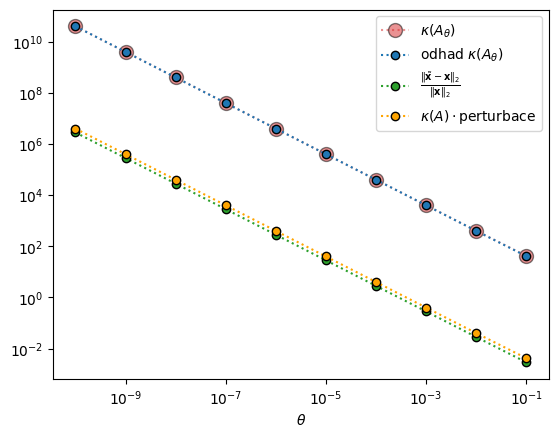

In [ ]:
def f(theta, rho=None, k=None, a=None, b=None):
    """Input 'theta' jsou body ve kterych vyhodnocujeme, zbyle inputy jsou optional, jen pro experimentaci s ruznymi typy 'f(x)'."""
    return theta**2

N = 50
theta = np.linspace(1, 100, N)  # theta = np.logspace(0, 2, N)
f_theta = f(theta)

fig, [ax1, ax2, ax3] = plt.subplots(nrows=1, ncols=3, figsize=(13, 5))
ax1.plot(theta, f(theta), 'o:', color="tab:red", markeredgecolor="k")
ax1.set_xlabel(r"$\theta$"); ax1.set_ylabel(r"$f(\theta)$")
ax2.semilogy(theta, f(theta), 'o:', color="tab:blue", markeredgecolor="k"); ax2.set_xlabel(r"$\theta$")
ax3.loglog(theta, f(theta), 'o:', color="tab:green", markeredgecolor="k"); ax3.set_xlabel(r"$\theta$")
plt.show()

### Úloha A4: Aplikace

Systémy [(1)](#eq1) si vezmeme ze zjednodušené, ale reálné aplikace - jeden problém odpovídá "[difuzi](https://en.wikipedia.org/wiki/Diffusion)" (česky "sálání") a druhý "[advekci](https://en.wikipedia.org/wiki/Advection)-difuzi" (česky "proudění-sálání"). Detaily jsou nastíněné v anotaci funkcí `get_diffusion_problem(n)` a `get_advection_diffusion_problem(n)`, které pro daný integer $n$ vrací matici a pravou stranu a tím definují systémy

\begin{equation*}
A_{diff} \mathbf{x}_{diff} =  \mathbf{b}_{diff}
\quad \mathrm{a} \quad
A_{advdiff} \mathbf{x}_{advdiff} =  \mathbf{b}_{adv diff}.
\end{equation*}

Matice $A_{diff}$ je SPD a matice $A_{advdiff}$ je nenormální pro libovolné $n>2$. Po spuštění následujících dvou buněk s kódem se vykreslí vývoj chyby $\| \mathbf{e}_{k} \|_{1,2,\infty}$ jako funkce počtu iterací $k$ v *semi-logaritmickému měřítku v proměnné $y$* (tzn. přesně jako výše, viz [`plt.semilogy()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.semilogy.html)).

Na základě přednášky víme, že konvergenci stacionárních iteračních metod lze zaručit splněním

\begin{equation*} \rho(I-M^{-1}A) < 1 \qquad \mathrm{nebo} \qquad \|| I-M^{-1}A \|| < 1 \end{equation*}

pro libovolnou maticovou normu splňující $\|| X\mathbf{v} \|| \leq \|| X \|| \cdot \|| \mathbf{v} \||$.

Podmínka vpravo na normu iterační matice je vždy silnější než podmínka vlevo na spektrální poloměr iterační matice, ale v praxi často snáze ověřitelná (např. věta o konvergenci Jacobiho metody pro ostře diagonálně dominantní matice).



***Vlastnosti $A$ & $I-M^{-1}A$***

Pozor na přílišné zjednodušování - přestože $A_{diff}$ je SPD a tedy unitárně diagonalizovatelná, tak z toho neplyne, že $I-M^{-1}A_{diff}$ je také unitárně diagonalizovatelná (a analogicky pro $A_{advdiff}$).



***Charakterizace vlastních čísel skrze Rayleigho quotient***

Na [cvičení k částečnému problému vlastních čísel](week-05-eigenvalue-problem) si dokážeme následující charakterizaci největšíno a nejmenšího vlastního čísla pro obecnou symmetrickou & pozitivně definitní matici $A$. V Úloze B1 si dokážeme, že platí
  - $\lambda_{max} :=  \max\limits_{\lambda \, je \, vl. \, cislo \, A} \lambda = \max\limits_{\mathbf{x}\in \mathbb{R}^n, \, \mathbf{x}\neq 0} \tfrac{\mathbf{x}^TA\mathbf{x}}{\mathbf{x}^T\mathbf{x}}, \qquad (*)$
  - $\lambda_{min} :=  \min\limits_{\lambda \, je \, vl. \, cislo \, A} \lambda = \min\limits_{\mathbf{x}\in \mathbb{R}^n, \, \mathbf{x}\neq 0} \tfrac{\mathbf{x}^TA\mathbf{x}}{\mathbf{x}^T\mathbf{x}}. \qquad (**)$

Tahle charakterizace stačí  na to, abychom plně porozuměli průběhu konvergence, kterou jsme vykreslili, za použití norem a spektrálních poloměrů. Při detailnějším čtení funkce `get_diffusion_problem(n)` vidíme, že

\begin{equation*} A_{diff} = (n+1)^2 \begin{bmatrix} 2 & -1 \\ -1 & \ddots & \ddots \\ & \ddots & \ddots & -1 \\ & & -1 & 2  \end{bmatrix} \in \mathbb{R}^{n\times n}. \end{equation*}

<div style="border-left: 4px solid #0969da; background-color: #ddf4ff; padding: 0.75em 1em; border-radius: 4px; margin: 1em 0;">
<blockquote style="margin: 0; padding: 0; border: none;">

**📝 Tužka a papír**


Ukažte, že $A_{diff}$ je symetrická & pozitivně-definitní.

Pro Jacobiho metodu

- Vyjádřete iterační matici $T = I - M^{-1}A_{diff}$ pomocí $A_{diff}$.
- Ukažte, že $I-T$ a $I+T$ jsou pozitivně definitní.
- Ukažte, že $\rho(T) < 1$.
- Ukažte, že Jacobiho metoda konverguje monotónně.

- [Nápovědy & hinty](#head-w02-hinty-a4)

</blockquote>
</div>

In [ ]:
# Je nutne tuto bunku spustit, neni nutne (a asi ani vhodne) v ni cokoliv
# psat/menit.  # Anotaci funkci si muzete precist (jinak bych se s tim nepsal),
# ale neni stezejni k pokracovani cvika.  # Lze v klidu pokracovat s tim, ze mame
# preddefinovane 2 funkce, ktere nam kazda vraceji matici a pravou stranu, ktere
# "nejsou uplne vycucane z prstu".

def get_diffusion_problem(n):
    '''
    Vrati nam matici "A" a vektor prave strany "b" t., ze reseni aproximuje "asymptoticke rozlozeni teploty vody v trubce" - pro zajemce, odpovida to nasledujicimu set-upu:
      - Predstavime si 1D trubku, ktere je plna vody a je na obou koncich uzavrena.
      - Na levy okraj trubky priplacneme ohrivak o teplote 100 °C.
      - Na pravy okraj trubky priplacneme led o teplote 0 °C.
      - Budeme predpokladat, ze mimo okraju trubka perfektne izoluje, tj. jedine tepelne zdroje jsou na okrajich. Take budeme predpokladat, ze nam led nikdy neroztaje.
      - Otazka, kterou si muzeme polozit : kdyz nechame trubku dostatecne dlouho v klidu, jak bude vypadat teplota vody v trubce?
      - Nejjednodussi zpusob aproximace vysledneho teplotniho profilu vody v trubce vede na problem Ax=b
    Proc ma "A" a "b" vypadat zrovna takhle se muzete dozvedet napr. v predmetu "NMMA338: Numerické řešení parciálních diferenciálních rovnic".
    '''
    h = 1 / (n + 1)
    A = 1 / h**2 * (2 * np.diag(np.ones(n), 0) - np.diag(np.ones(n - 1), -1) - np.diag(np.ones(n - 1), 1))
    left_dirichlet_bc = 100
    b = np.zeros(n)
    b[0] = 1 / h**2 * left_dirichlet_bc
    return A, b


def get_advection_diffusion_problem(n, adv_coeff=2.15):
    '''
    Vrati nam matici "A" a vektor prave strany "b" t., ze reseni aproximuje "asymptoticke rozlozeni teploty vody v trubce" - pro zajemce, odpovida to nasledujicimu set-upu:
      - Stejne jako vyse :
        - Predstavime si 1D trubku, ktere je plna vody a je na obou koncich uzavrena.
        - Na levy okraj trubky priplacneme ohrivak o teplote 100 °C.
        - Na pravy okraj trubky priplacneme led o teplote 0 °C.
        - Budeme predpokladat, ze mimo okraju trubka perfektne izoluje, tj. jedine tepelne zdroje jsou na okrajich. Take budeme predpokladat, ze nam led nikdy neroztaje.
      - Navic si situaci udelame zajimavejsi tim, ze
        - Vyvrtame v obou koncich trubky diru.
        - Levym okrajem nechame do trubky proudit vodu o teplote 100 °C (predehratou).
        - Pravym okrajem nechame z trubky vytekat vodu o teplote 0 °C (ochlazenou v dusledku ledu na zbytkupraveho okraje).
        - "Silu proudu" zleva doprava budeme kontrolovat koeficientem "adv_coeff" - mel by byt v intervalu [0,+nekonecno) - cim vyssi, tim silnejsi proud.
        - Zanedbame turbulence/viry vodniho toku uvnitr trubky.
      - Prirozena intuice je, ze
        - pokud "adv_coeff=0", pak dostaneme zpatky "diffusion_problem".
        - pokud "adv_coeff>>0", pak nam silny proud nazene teplo z leveho okraje i dost blizko chlazeni na pravem okraji.

      - Otazka, kterou si muzeme polozit : kdyz nechame trubku dostatecne dlouho v klidu, jak bude vypadat teplota vody v trubce?
        - pokud "adv_coeff=0", pak ocekavame, ze se teplota rovnomerne rozprostre mezi 100 °C a 0 °C podel cele trubky.
        - pokud "adv_coeff>>0", pak ocekavame, ze se teplota bude blizko 100 °C i vyrazne dale od leveho konce, protoze ji tam proud neustale unasi a pravy konec ji "nestiha uchladit".
      - Nejjednodussi zpusob aproximace vysledneho teplotniho profilu vody v trubce vede na problem Ax=b
    Proc ma "A" a "b" vypadat zrovna takhle se muzete dozvedet napr. v predmetu "NMMA338: Úvod do parciálních diferenciálních rovnic".
    '''
    h = 1 / (n + 1)
    adv_coeff = adv_coeff / h  # "adv_coeff ~ 1/DiscretePeclet"
    A = (1 / h**2 * (2 * np.diag(np.ones(n), 0) - np.diag(np.ones(n - 1), -1) - np.diag(np.ones(n - 1), 1))
         + adv_coeff * 1 / (2 * h) * (np.diag(np.ones(n - 1), 1) - np.diag(np.ones(n - 1), -1)))
    left_dirichlet_bc = 100
    b = np.zeros(n)
    b[0] = 1 / h**2 * left_dirichlet_bc + adv_coeff * 1 / (2 * h) * left_dirichlet_bc
    return A, b


# Demo
n = 100  # parametr urcujici "presnost aproximace". Cim vetsi, tim lepsi, ale pro n>>1000 to bude bezet netrivialne dlouho

# sestavime A, b pro problem "difuze"
A, b = get_diffusion_problem(n)
u_diff = np.linalg.solve(A, b)
x = np.linspace(0, 100, n + 2)
u_diff_bc = np.concatenate((np.array([100]), u_diff, np.array([0])))

# sestavime A, b pro problem "advekce-difuze"
adv_coeff = 1 / 10  # cislo z intervalu (0,+infty) -> pro "adv_coeff >> 2" ocekavame numerickou nestabilitu
A, b = get_advection_diffusion_problem(n, adv_coeff)
u_advdiff = np.linalg.solve(A, b)
u_advdiff_bc = np.concatenate((np.array([100]), u_advdiff, np.array([0])))

fig, [ax1, ax2] = plt.subplots(nrows=1, ncols=2, sharex=True, sharey=False, figsize=(20, 6))

ax1.plot(x, u_diff_bc, '-', lw=2, c='tab:green')
ax1.yaxis.set_tick_params(labelsize=15); ax1.xaxis.set_tick_params(labelsize=15)
ax1.set_ylabel('teplota vody uvnitr trubky [°C]', fontsize=15)
ax1.set_xlabel('vzdalenost od leveho okraje v trubce [cm]', fontsize=15)
ax1.set_title(r"'Difuze': zadny pritok ani odtok", fontsize=20)

ax2.plot(x, u_advdiff_bc, '-', lw=2, c='tab:green')
ax2.yaxis.set_tick_params(labelsize=15); ax2.xaxis.set_tick_params(labelsize=15)
ax2.set_ylabel('teplota vody uvnitr trubky [°C]', fontsize=15)
ax2.set_xlabel('vzdalenost od leveho okraje v trubce [cm]', fontsize=15)
ax2.set_title(r"'Advekce-difuze': diry s pritokem a odtokem", fontsize=20)
plt.show()

In [ ]:
# vypocet Jacobi & Gauss-Seidel iteraci pro nase dva systemy

def rel_error_curve(x_approx, x_exact, ord):
    '''Relativni chyba ||x_approx[k,:] - x_exact|| / ||x_approx[0,:] - x_exact|| pro kazde k.'''
    errors = np.linalg.norm(x_approx - x_exact, axis=1, ord=ord)
    return errors / np.linalg.norm(x_approx[0, :] - x_exact, ord=ord)


############# zmenit po naimplementovani Gauss-Seidel #############
GaussSeidel_JeNaimplementovany = False
############# zmenit po naimplementovani Gauss-Seidel #############


n_iter = 150  # pocet iteraci provedenych Jacobiho a Gauss-Seidelem
n = 100
x0 = np.random.rand(n)

# problem "difuze"
A_diff, b_diff = get_diffusion_problem(n)
u_diff = np.linalg.solve(A_diff, b_diff)
x_diff_jac = jacobi_method(A_diff, b_diff, x0, n_iter)
if GaussSeidel_JeNaimplementovany :
    x_diff_gs = gauss_seidel_method(A_diff, b_diff, x0, n_iter)

err_diff_jac_1 = rel_error_curve(x_diff_jac, u_diff, 1)
err_diff_jac_2 = rel_error_curve(x_diff_jac, u_diff, 2)
err_diff_jac_inf = rel_error_curve(x_diff_jac, u_diff, np.inf)
if GaussSeidel_JeNaimplementovany :
    err_diff_gs_1 = rel_error_curve(x_diff_gs, u_diff, 1)
    err_diff_gs_2 = rel_error_curve(x_diff_gs, u_diff, 2)
    err_diff_gs_inf = rel_error_curve(x_diff_gs, u_diff, np.inf)
else :
    err_diff_gs_1 = np.zeros_like(err_diff_jac_1)
    err_diff_gs_2 = np.zeros_like(err_diff_jac_1)
    err_diff_gs_inf = np.zeros_like(err_diff_jac_1)

# problem "advekce-difuze"
A_advdiff, b_advdiff = get_advection_diffusion_problem(n)
u_advdiff = np.linalg.solve(A_advdiff, b_advdiff)
x_advdiff_jac = jacobi_method(A_advdiff, b_advdiff, x0, n_iter)
if GaussSeidel_JeNaimplementovany :
    x_advdiff_gs = gauss_seidel_method(A_advdiff, b_advdiff, x0, n_iter)

err_advdiff_jac_1 = rel_error_curve(x_advdiff_jac, u_advdiff, 1)
err_advdiff_jac_2 = rel_error_curve(x_advdiff_jac, u_advdiff, 2)
err_advdiff_jac_inf = rel_error_curve(x_advdiff_jac, u_advdiff, np.inf)
if GaussSeidel_JeNaimplementovany :
    err_advdiff_gs_1 = rel_error_curve(x_advdiff_gs, u_advdiff, 1)
    err_advdiff_gs_2 = rel_error_curve(x_advdiff_gs, u_advdiff, 2)
    err_advdiff_gs_inf = rel_error_curve(x_advdiff_gs, u_advdiff, np.inf)
else :
    err_advdiff_gs_1 = np.zeros_like(err_advdiff_jac_1)
    err_advdiff_gs_2 = np.zeros_like(err_advdiff_jac_1)
    err_advdiff_gs_inf = np.zeros_like(err_advdiff_jac_1)

In [ ]:
# predikce konvergence Jacobi & Gauss-Seidel iteraci - spektralni polomer a normy iteracni matice

def iteration_matrix_stats(A, M):
    '''Pro stepeni A = M - N spocita spektralni polomer iteracni matice I - M^{-1}A a jeji normy 1, 2, nekonecno.'''
    N = M - A
    iter_matrix = np.linalg.solve(M, N)
    spectral_radius = np.max(np.abs(np.linalg.eigvals(iter_matrix)))
    norm1 = np.linalg.norm(iter_matrix, ord=1)
    norm2 = np.linalg.norm(iter_matrix, ord=2)
    norm_inf = np.linalg.norm(iter_matrix, ord=np.inf)
    return spectral_radius, norm1, norm2, norm_inf


show_norm_estimates = True

if show_norm_estimates:
    # problem "difuze" - pracujeme s matici A = A_diff
    rho_diff_jac, norm1_diff_jac, norm2_diff_jac, norm_inf_diff_jac = iteration_matrix_stats(A_diff, np.diag(np.diag(A_diff)))
    if GaussSeidel_JeNaimplementovany :
        rho_diff_gs, norm1_diff_gs, norm2_diff_gs, norm_inf_diff_gs = iteration_matrix_stats(A_diff, np.tril(A_diff))
    else :
        rho_diff_gs, norm1_diff_gs, norm2_diff_gs, norm_inf_diff_gs = np.nan, np.nan, np.nan, np.nan

    # problem "advekce-difuze" - pracujeme s matici A = A_advdiff
    rho_advdiff_jac, norm1_advdiff_jac, norm2_advdiff_jac, norm_inf_advdiff_jac = iteration_matrix_stats(A_advdiff, np.diag(np.diag(A_advdiff)))
    if GaussSeidel_JeNaimplementovany :
        rho_advdiff_gs, norm1_advdiff_gs, norm2_advdiff_gs, norm_inf_advdiff_gs = iteration_matrix_stats(A_advdiff, np.tril(A_advdiff))
    else :
        rho_advdiff_gs, norm1_advdiff_gs, norm2_advdiff_gs, norm_inf_advdiff_gs = np.nan, np.nan, np.nan, np.nan

In [ ]:
# vykreslovani

def plot_error_panel(ax, err_jac, err_gs, iterations, rho_jac, rho_gs, norm_jac, norm_gs,
                      norm_symbol, ylim_scale, legend_loc, title=None, ylabel=None):
    ax.semilogy(err_jac, 'o', lw=0, markerfacecolor='tab:red', markeredgecolor='k', ms=12)
    ax.semilogy(err_gs, 's', lw=0, markerfacecolor='tab:blue', markeredgecolor='k', ms=12)
    ax.yaxis.set_tick_params(labelsize=15)
    ax.xaxis.set_tick_params(labelsize=15)
    ax.set_ylim(ylim_scale[0] * min(err_gs.min(), err_jac.min()), ylim_scale[1] * max(err_gs.max(), err_jac.max()))
    if title is not None:
        ax.set_title(title, fontsize=20)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=20)

    if show_norm_estimates:
        ax.semilogy(rho_gs**iterations, ':', color='tab:blue', lw=4)
        ax.semilogy(rho_jac**iterations, ':', color='tab:red', lw=4)
        blank_line, = ax.plot([10, 11], [0.9, 0.8], '-', lw=0, color='white')
        labels = [
            r'Jacobi: $\|I-M^{-1}A\|_{' + norm_symbol + r'} \approx $' + '{:.2e}'.format(norm_jac),
            r'Gauss-Seidel: $\|I-M^{-1}A\|_{' + norm_symbol + r'} \approx $' + '{:.2e}'.format(norm_gs),
        ]
        ax.legend([blank_line, blank_line], labels, loc=legend_loc, fancybox=True, shadow=True, ncol=1, fontsize=15)


fig, [[ax1, ax2, ax3], [ax4, ax5, ax6]] = plt.subplots(nrows=2, ncols=3, sharex=True, sharey=False, figsize=(22, 9))
iterations = np.arange(0, n_iter + 1, 1, dtype=np.float64)

plot_error_panel(ax1, err_diff_jac_1, err_diff_gs_1, iterations, rho_diff_jac, rho_diff_gs, norm1_diff_jac, norm1_diff_gs,
                  '1', (0.95, 1.05), 'lower left',
                  title=r"Pouzita norma: $\| \cdot \|_{1}$", ylabel=r"normalni matice (diff)")
plot_error_panel(ax2, err_diff_jac_2, err_diff_gs_2, iterations, rho_diff_jac, rho_diff_gs, norm2_diff_jac, norm2_diff_gs,
                  '2', (0.95, 1.05), 'lower left',
                  title=r"Pouzita norma: $\| \cdot \|_{2}$")
plot_error_panel(ax3, err_diff_jac_inf, err_diff_gs_inf, iterations, rho_diff_jac, rho_diff_gs, norm_inf_diff_jac, norm_inf_diff_gs,
                  r'\infty', (0.95, 1.05), 'lower left',
                  title=r"Pouzita norma: $\| \cdot \|_{\infty}$")

plot_error_panel(ax4, err_advdiff_jac_1, err_advdiff_gs_1, iterations, rho_advdiff_jac, rho_advdiff_gs, norm1_advdiff_jac, norm1_advdiff_gs,
                  '1', (0.3, 3), 'lower right', ylabel=r"ne-normalni matice (adv-diff)")
plot_error_panel(ax5, err_advdiff_jac_2, err_advdiff_gs_2, iterations, rho_advdiff_jac, rho_advdiff_gs, norm2_advdiff_jac, norm2_advdiff_gs,
                  '2', (0.3, 3), 'lower right')
plot_error_panel(ax6, err_advdiff_jac_inf, err_advdiff_gs_inf, iterations, rho_advdiff_jac, rho_advdiff_gs, norm_inf_advdiff_jac, norm_inf_advdiff_gs,
                  r'\infty', (0.3, 3), 'lower right')

ax = plt.gca()
fig = plt.gcf()
line1, = ax.plot([1, 1], [1, 1], '-o', lw=0, markerfacecolor='tab:red', markeredgecolor='k', ms=12)
line2, = ax.plot([1, 1], [1, 1], '-s', lw=0, markerfacecolor='tab:blue', markeredgecolor='k', ms=12)
all_handles = [line1, line2]
all_labels = [r'Jacobi', r'Gauss-Seidel']
if show_norm_estimates:
    line3, = ax.plot([100, 101], [1e-5, 1e-7], ':', lw=5, color='tab:gray')
    ax.plot([100, 101], [1e-5, 1e-7], '-', lw=10, color='white')
    all_handles.append(line3)
    all_labels.append(r'sklon $\rho(I - M^{-1}A)^k$')
fig.legend(all_handles, all_labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), fancybox=True, shadow=True, ncol=3, fontsize=30)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## Část B: Stacionární metody & polynomy

Stacionární metody byly populární v druhé polovině minulého století, ale jejich popularita začala ustupovat ve prospěch tzv. [metod Krylovovských prostorů](https://en.wikipedia.org/wiki/Krylov_subspace#Existing_methods) - o Krylovovské prostory ještě potkáme v rámci problému vlastních čísel.

My se podíváme právě na přechod od stacionárních metod ke Krylovovským pro nejjednodušší stacionární metodu - [Richardsonovu metodu](https://en.wikipedia.org/wiki/Modified_Richardson_iteration), která odpovídá volbě $M=I$, $N = I-A$ a je tedy definována iterací
\begin{equation*} \mathbf{x}_{k} = (I-A)\mathbf{x}_{k-1} +\mathbf{b} = \mathbf{x}_{k-1} + (\mathbf{b} - A\mathbf{x}_{k-1}).\end{equation*}

Zároveň připomeneme, že pro matice umíme definovat *polynomy matic* pro libovlnou čtvercovou matici - například pro $X\in \mathbb{R}^{n\times n}$ a pro polynom $p(t) := t^2-4t+3 = (t-3)(t-1)$ platí
\begin{equation*} p(X) = X^2-4X+2I_n = (X-3I_n)(X-I_n). \end{equation*}

### Úloha B1 - Richardsonova metoda & Krylov

<div style="border-left: 4px solid #0969da; background-color: #ddf4ff; padding: 0.75em 1em; border-radius: 4px; margin: 1em 0;">
<blockquote style="margin: 0; padding: 0; border: none;">

**📝 Tužka a papír**


- Na základě rekurence pro aproximace $\mathbf{x}_k$ Richardsonovy metody odvoďte rekurenci pro *rezidua* Richardsonovy metody.

- Pomocí této rekurence najděte reálný polynom $q_2(t)$, pro který platí $\mathbf{r}_2 = q_2(I-A) \mathbf{r}_0$. Následně zobecněte pro $k$-té reziduum a najděte příslušný $q_k(t)$ stupně nejvýše $k$.
  
- Najděte reálný polynom $p_k(t)$ stupně nejvýše $k$, pro který platí $\mathbf{r}_k = p_k(A) \mathbf{r}_0$.

- Ukažte

\begin{equation*}\left\{ f_k(A) \mathbf{v}_0 \, | \, f_k(t) \; \mathrm{je \; polynom} \; \& \; \mathrm{deg}(f_k) \leq  k-1 \; \& \; f_k(0)=1 \right\}  = \mathbf{v}_0 + A \cdot \mathrm{span} \left( \mathbf{v}_0, A\mathbf{v}_0, \dotsc , A^{k-1}\mathbf{v}_0  \right)\end{equation*}

- [Nápověda & hinty](#head-w02-hinty-b1)

</blockquote>
</div>

Jinými slovy, Richardsonova metoda konstruuje aproximace $\mathbf{x}_k$ tak, že rezidua $\mathbf{r}_k$ leží v prostoru

\begin{equation*} \mathbf{r}_0 + A \cdot \underbrace{ \, \mathrm{span} \left( \mathbf{r}_0, A\mathbf{r}_0, \dotsc , A^{k-1}\mathbf{r}_0  \right) \, }_{=: \, \mathcal{K}_{k}(A,\mathbf{r}_0)} \, \equiv \,  \mathbf{r}_0 + A \cdot \mathcal{K}_{k}(A,\mathbf{r}_0) ,\end{equation*}

který je definován pomocí $\mathcal{K}_{k}(A,\mathbf{r}_0) $, tzv. [$k$-tého Krylovova podprostoru příslušejícího $A$ a $\mathbf{r}_0$](https://en.wikipedia.org/wiki/Krylov_subspace).


Iterační metody, které jsou dnes asi nejvíce používané fungují jako "vylepšováky" tohoto postupu. Volí $\mathbf{x}_k$ tak, aby stále platilo

\begin{equation*}\mathbf{r}_k \in  \mathbf{r}_0 + A \cdot \mathcal{K}_{k}(A,\mathbf{r}_0),\end{equation*}

protože se dá ukázat, že to je z výpočetního hlediska vhodné/přirozené, ale snaží se "v jistém smyslu optimalizovat aproximaci $\mathbf{x}_k$" - například minimalizovat $\|\mathbf{r}_k\|$. Jinými slovy, nevolí vždy "stejný polynom $p_k(t)$", ale adaptují ho v každé iteraci na základě předešlých iterací. Těmto metodám se říká metody Krylovovských prostorů a více se o nich dozvíte během 3. ročníku, například v rámci předmětu [NMNM331: Analýza maticových výpočtů 1](https://is.cuni.cz/studium/predmety/index.php?do=predmet&kod=NMNM331).

<div style="border-left: 4px solid #8250df; background-color: #fbefff; padding: 0.75em 1em; border-radius: 4px; margin: 1em 0;">
<blockquote style="margin: 0; padding: 0; border: none;">

**❗ ZÚ (semestrální projekt) — Krylov pro obecné štěpení**

**Tužka a papír**:

  - Na základě rekurence pro chybu $\mathbf{e}_k = \mathbf{x} - \mathbf{x}_k$ obecné stacionární metody založené na štěpení $A=M-N$ (máme ji na začátku worksheetu) odvoďte rekurenci pro *rezidua*.

  - Analogicky k postupu v Úloze B1 vyjádřete $k$-té reziduum $\mathbf{r}_k$ jako nějaký reálný polynom $p_k(t)$ stupně nejvýše $k$ a splňující $p_k(0)=1$ v nějaké matici $X$ aplikovaný na počáteční reziduum, tj. najděte polynom $p_k(t)$ (stupně nejvýše $k$) a matici $X$ takové, že platí $\mathbf{r}_k = p_k(X) \mathbf{r}_0$ a zároveň $p_k(0)=1$.

  - S jakým Krylovovským podprostorem takto implicitně pracujeme?

</blockquote>
</div>

## Hinty

<a name="head-w02-hinty-a1"></a>
### Hinty A1

#### Hint "užitečné funkce"

Budou se vám hodit funkce <a href="https://numpy.org/doc/2.3/reference/generated/numpy.diag.html">np.diag()</a> a <a href="https://numpy.org/doc/stable/reference/generated/numpy.tril.html">np.tril()</a> a také <a href="https://numpy.org/doc/stable/reference/generated/numpy.triu.html">np.triu()</a>.

#### Hint "neužitečné funkce"

Bude se vám hodit funkce <a href="https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html">np.linalg.solve()</a> - naopak se *vyvarujte* funkce <a href="https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html">np.linalg.inv()</a>

#### Hint "kostra kódu"

  Kostra Vašeho kódu by mohla vypadat přibližně takto:

  ```
  # Inicializaci pole do ktereho si budeme ukladat aproximace x0, x1, ...
  x_approx = np.zeros(( ... , ... ))
  x_approx[0,:] = ...

  # Volba konkretniho stepeni
  M = ...
  N = ...

  # Provedeni potrebneho kroku metody
  for k in range(n_iter):
      x_approx[k+1,:] = ...
  ```

<a name="head-w02-hinty-a2"></a>
### Hinty A2

#### Hint "unitární" 1

Využijte vlastnosti unitárních matic, tj. $\|U\mathbf{x}\| = \|\mathbf{x}\|$.

#### Hint "unitární" 2

Pokud máme reálnou diagonální matici $D$ a označíme její největší prvek v absolutní hodnotě $d_{\mathrm{max}}$, pak platí

\begin{equation*} \frac{|| D^{k+1} ||}{|| D^{k} ||} = \frac{|d_{\mathrm{max}}|^{k+1}}{|d_{\mathrm{max}}|^k} \frac{|| \left( \tfrac{1}{d_{\mathrm{max}}} D \right)^{k+1} ||}{|| \left( \tfrac{1}{d_{\mathrm{max}}} D \right)^{k} ||}.\end{equation*}

#### Hint "diagonalizovatelná" 1

Vezměme si diagonalizovatelnou matici $X$, která není unitárně diagonalizovatelná. Co umíme (jestli vůbec něco) říct o souvislosti

\begin{equation*} || X ||_2 := \max\limits_{||\mathbf{v}||=1} ||X\mathbf{v}|| \qquad \mathrm{a} \qquad \rho(X) := \max\limits_{\lambda \, \mathrm{je\, vl.\, c. \,} X} |\lambda |, \end{equation*}

pro unitárně diagonalizovatelné matice a co pro ne-unitárně diagonalizovatelné?

#### Hint "diagonalizovatelná" 2

Pro důkaz lze použít stejnou myšlenku jako pro unitárně diagonalizovatelnou iterační matici, ale technika se musí přizpůsobit tomu, že přechod do vlastní báze už může měnit normu. Navrhněte horní a spodní odhad

\begin{equation*} c_{min} \leq \| S D^k S^{-1} \mathbf{e}_0 \| \leq C_{max}, \end{equation*}

který respektuje ideu důkazu konvergence (viz Hint 2 pro unitárně diagonalizovatelné).

#### Hint "diagonalizovatelná" 3

Pro odhady z předchozího hintu se stačí trojúhelníková nerovnost.

<a name="head-w02-hinty-a3"></a>
### Hinty A3

#### Hint "vlastnosti grafů sup- & sub-lineární konvergence"

Ukažte, že semilogaritmický graf chyby (konvergující superlineárně k $0$) od určitého $k_0$ leží pod spojnicemi bodů $(k,\log_{10}(\|e_{k}\|)$ a $(k+1,\log_{10}(\|e_{k+1}\|)$. Analogická myšlenka by měla fungovat i pro sublineární konvergenci. Vzpomeňte si na definici konvexních/konkávních funkcí.

<a name="head-w02-hinty-a4"></a>
### Hinty A4

#### Hint "pozitivně definitní"

Pozitivní definitnost ukažte z definice, tj. $\mathbf{x}^TL\mathbf{x} > 0$ pro libovolné $\mathbf{x} \neq \mathbf{0}$.

#### Hint "spektrální poloměr" 1

Zjevně $\rho(T) = \max \{ \lambda_{min} ,\lambda_{max} \}$. Využijte charakterizace $(*)$ a $(**)$.

#### Hint "spektrální poloměr" 2

Pokud je $I-T$ pozitivně definitní, pak jistě platí $\mathbf{x}^T\mathbf{x} - \mathbf{x}^TT\mathbf{x} > 0$.

<a name="head-w02-hinty-b1"></a>
### Hinty B1

#### Hint "jak začít?"


Pro aproximaci $\mathbf{x}_k$ řešení systému $A\mathbf{x} = \mathbf{b}$ je reziduum definováno jako $A(\mathbf{x}-\mathbf{x}_k) = \mathbf{b} - A\mathbf{x}_k$, kde $\mathbf{x}$ je přesné řešení.

#### Hint "polynomy"

Ukažte, že libovolný polynom $p_k$ stupně nejvýše $k$, pro který platí $p_k(0)=1$, lze zapsat jako $p_k(t)=1 + t\cdot \tilde{p}_{k-1}(t)$ pro nějaký polynom $\tilde{p}_{k-1}(t)$ stupně nejvýše $k-1$.